In [1]:
"""
shard_data.py
-------------
Shards the BoT-IoT preprocessed data into N client partitions with mild Non-IID.

Usage:
    python shard_data.py --data_path /path/to/botiot.csv \
                         --num_clients 5 \
                         --output_dir ./client_data \
                         --alpha 0.5

Non-IID control:
    alpha (Dirichlet concentration):
        - Lower  (0.1)  → very non-iid  (each client sees few classes)
        - Medium (0.5)  → mild non-iid  ← recommended for this imbalanced dataset
        - Higher (5.0)  → near-iid
"""

import argparse
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────────────────────
# Preprocessing (mirrors your main project)
# ─────────────────────────────────────────────────────────────

def preprocess(df, target='category'):
    columns_to_keep = [
        'pkSeqID', 'stime', 'flgs', 'flgs_number', 'proto', 'proto_number',
        'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state',
        'state_number', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min',
        'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate',
        'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto',
        'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP',
        'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport',
        'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP',
        'Pkts_P_State_P_Protocol_P_SrcIP', 'attack', 'category', 'subcategory'
    ]
    df = df[[c for c in columns_to_keep if c in df.columns]].copy()
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.duplicated()]

    le = LabelEncoder()
    y = le.fit_transform(df[target])
    classes = le.classes_
    print(f"\nTarget: {target} | Classes: {list(classes)}")

    drop_cols = ['pkSeqID', 'stime', 'ltime', 'saddr', 'sport', 'daddr', 'dport',
                 'attack', 'category', 'subcategory']
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    X = X.fillna(0)

    cat_cols = [c for c in ['flgs', 'proto', 'state'] if c in X.columns]
    num_cols = [c for c in X.columns if c not in cat_cols]

    for col in cat_cols:
        cle = LabelEncoder()
        X[col] = cle.fit_transform(X[col].astype(str))

    X_arr = X.values.astype(np.float32)
    num_idx = [X.columns.tolist().index(c) for c in num_cols]
    scaler = StandardScaler()
    X_arr[:, num_idx] = scaler.fit_transform(X_arr[:, num_idx])

    print(f"Dataset shape: {X_arr.shape}")
    return X_arr, y, classes


# ─────────────────────────────────────────────────────────────
# Non-IID Dirichlet Sharding
# ─────────────────────────────────────────────────────────────

def dirichlet_partition(y, num_clients, alpha, seed=42):
    """
    Partition indices using a Dirichlet distribution over class labels.
    alpha controls non-iid-ness: lower = more non-iid.
    """
    np.random.seed(seed)
    classes = np.unique(y)
    n_classes = len(classes)

    # For each class, draw proportions for clients
    client_indices = [[] for _ in range(num_clients)]

    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        np.random.shuffle(cls_idx)

        # Draw proportions from Dirichlet
        proportions = np.random.dirichlet(alpha=np.repeat(alpha, num_clients))

        # Split indices according to proportions
        splits = (proportions * len(cls_idx)).astype(int)
        # Fix rounding so we don't lose samples
        splits[-1] = len(cls_idx) - splits[:-1].sum()

        start = 0
        for c, size in enumerate(splits):
            client_indices[c].extend(cls_idx[start:start + size].tolist())
            start += size

    # Shuffle within each client
    for c in range(num_clients):
        np.random.shuffle(client_indices[c])

    return client_indices


# ─────────────────────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────────────────────

def plot_distribution(y, client_indices, classes, output_dir):
    num_clients = len(client_indices)
    n_classes = len(classes)

    dist = np.zeros((num_clients, n_classes), dtype=int)
    for c, idxs in enumerate(client_indices):
        for cls in range(n_classes):
            dist[c, cls] = np.sum(y[idxs] == cls)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Stacked bar chart
    bottom = np.zeros(num_clients)
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    for cls in range(n_classes):
        axes[0].bar(range(num_clients), dist[:, cls],
                    bottom=bottom, label=classes[cls], color=colors[cls])
        bottom += dist[:, cls]
    axes[0].set_title('Class Distribution per Client', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Client ID')
    axes[0].set_ylabel('Sample Count')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_xticks(range(num_clients))

    # Heatmap of proportions
    prop = dist / dist.sum(axis=1, keepdims=True)
    sns.heatmap(prop, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=classes, yticklabels=[f'Client {i}' for i in range(num_clients)],
                ax=axes[1])
    axes[1].set_title('Class Proportion per Client', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Class')

    plt.tight_layout()
    path = os.path.join(output_dir, 'data_distribution.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Distribution plot saved → {path}")


# ─────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description='Shard BoT-IoT for Federated Learning')
    parser.add_argument('--data_path', type=str, required=True,
                        help='Path to the BoT-IoT CSV file')
    parser.add_argument('--num_clients', type=int, default=5,
                        help='Number of FL clients')
    parser.add_argument('--target', type=str, default='category',
                        choices=['attack', 'category', 'subcategory'],
                        help='Classification target')
    parser.add_argument('--alpha', type=float, default=0.5,
                        help='Dirichlet alpha (0.1=very non-iid, 0.5=mild, 5.0=near-iid)')
    parser.add_argument('--output_dir', type=str, default='./client_data',
                        help='Output directory for client shards')
    parser.add_argument('--test_split', type=float, default=0.2,
                    help='Fraction of data to hold out as global test set')
    
    parser.add_argument('--seed', type=int, default=42)
    args = parser.parse_args()

    os.makedirs(args.output_dir, exist_ok=True)

    print("=" * 60)
    print("  BoT-IoT FL Data Sharding")
    print("=" * 60)
    print(f"  Clients  : {args.num_clients}")
    print(f"  Target   : {args.target}")
    print(f"  Alpha    : {args.alpha}  (Dirichlet non-IID)")
    print(f"  Output   : {args.output_dir}")
    print("=" * 60)

    # Load data
    print(f"\nLoading data from: {args.data_path}")
    df = pd.read_csv(args.data_path, low_memory=False)
    print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

    from sklearn.model_selection import train_test_split

    X, y, classes = preprocess(df, target=args.target) 

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=args.test_split, stratify=y, random_state=args.seed)
    np.save(os.path.join(args.output_dir, 'test_X.npy'), X_test)
    np.save(os.path.join(args.output_dir, 'test_y.npy'), y_test)
    print(f"Global test set: {len(y_test):,} samples → {args.output_dir}/test_X.npy")
    

    print(f"\nPartitioning with Dirichlet(alpha={args.alpha}) ...")
    client_indices = dirichlet_partition(y_train, args.num_clients, args.alpha, args.seed)  # ← y → y_train

    # Save global test shard
    np.save(os.path.join(args.output_dir, 'test_X.npy'), X_test)
    np.save(os.path.join(args.output_dir, 'test_y.npy'), y_test)
    print(f"Global test set: {len(y_test):,} samples → {args.output_dir}/test_X.npy")

    # Partition
    print(f"\nPartitioning with Dirichlet(alpha={args.alpha}) ...")
    client_indices = dirichlet_partition(y, args.num_clients, args.alpha, args.seed)
    

    # Save each client's shard
    print("\nClient shard summary:")
    print(f"{'Client':<10} {'Samples':<10} {'Breakdown'}")
    print("-" * 60)

    for cid, idxs in enumerate(client_indices):
        idxs = np.array(idxs)
        X_c = X[idxs]
        y_c = y[idxs]

        # Save
        np.save(os.path.join(args.output_dir, f'client_{cid}_X.npy'), X_c)
        np.save(os.path.join(args.output_dir, f'client_{cid}_y.npy'), y_c)

        breakdown = {classes[cls]: int((y_c == cls).sum())
                     for cls in range(len(classes))}
        breakdown_str = ', '.join(f'{k}:{v}' for k, v in breakdown.items())
        print(f"  Client {cid:<4} {len(idxs):<10} {breakdown_str}")

    # Save metadata
    np.save(os.path.join(args.output_dir, 'classes.npy'), classes)
    meta = {
        'num_clients': args.num_clients,
        'target': args.target,
        'n_features': X.shape[1],
        'n_classes': len(classes),
        'alpha': args.alpha,
        'classes': list(classes)
    }
    import json
    with open(os.path.join(args.output_dir, 'meta.json'), 'w') as f:
        json.dump(meta, f, indent=2)

    print(f"\nMetadata saved → {args.output_dir}/meta.json")

    # Visualise
    #plot_distribution(y, client_indices, classes, args.output_dir)
    plot_distribution(y_train, client_indices, classes, args.output_dir)
    print("\nDone! ✓")


In [4]:
import kagglehub
azdinsahir_bot_iot_processed_path = kagglehub.dataset_download('azdinsahir/bot-iot-processed')
print('Data source import complete.')

Using Colab cache for faster access to the 'bot-iot-processed' dataset.
Data source import complete.


In [5]:
azdinsahir_bot_iot_processed_path

'/kaggle/input/bot-iot-processed'

  BoT-IoT FL Data Sharding
  Clients  : 5
  Target   : category
  Alpha    : 0.5  (Dirichlet non-IID)
  Output   : /content/client_data

Loading data from: /kaggle/input/bot-iot-processed/final_dataset.csv
Loaded 1,354,342 rows × 53 columns

Target: category | Classes: ['DDoS', 'DoS', 'Normal', 'Reconnaissance', 'Theft']
Dataset shape: (1354342, 36)
Global test set: 270,869 samples saved.

Partitioning with Dirichlet(alpha=0.5) ...

Client shard summary:
Client     Samples    Breakdown
------------------------------------------------------------
  Client 0    48052      DDoS:36191, DoS:7849, Normal:2739, Reconnaissance:1163, Theft:110
  Client 1    426627     DDoS:55241, DoS:18689, Normal:3416, Reconnaissance:349051, Theft:230
  Client 2    126706     DDoS:106587, DoS:65, Normal:1388, Reconnaissance:18567, Theft:99
  Client 3    388455     DDoS:78669, DoS:107857, Normal:7, Reconnaissance:201142, Theft:780
  Client 4    93633      DDoS:3104, DoS:1412, Normal:84, Reconnaissance:88982, Th

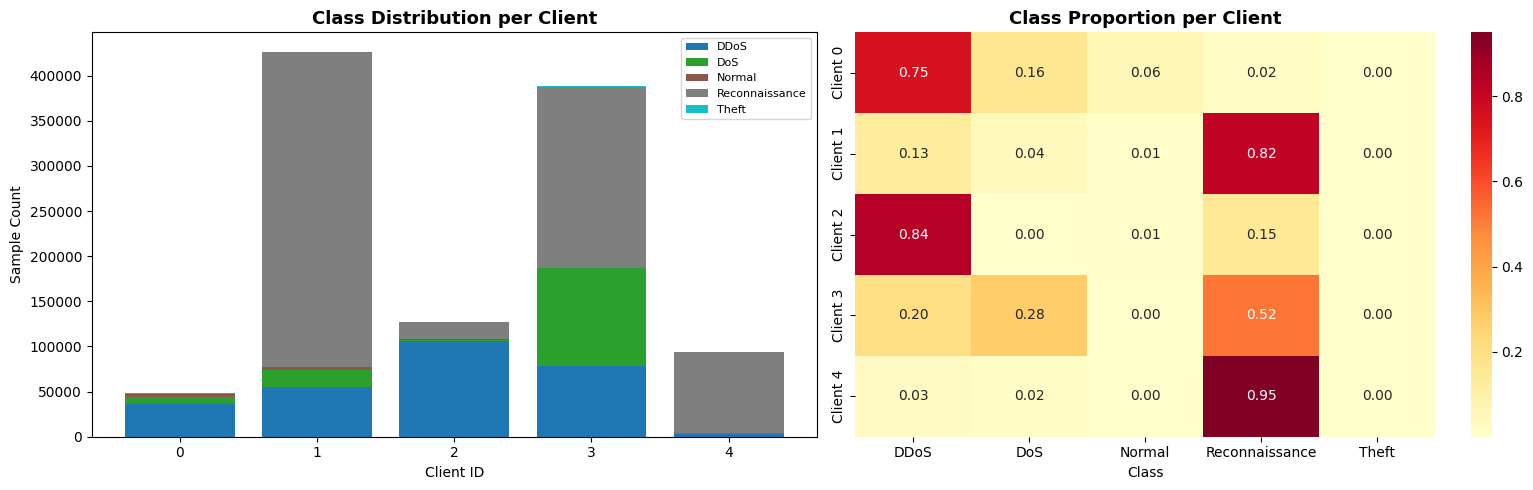

Distribution plot saved → /content/client_data/data_distribution.png

Done! ✓


In [6]:
import sys
sys.argv = ['']  # prevents argparse conflicts in notebooks

# ─── Set your params here ───────────────────────────────
DATA_PATH   = '/kaggle/input/bot-iot-processed/final_dataset.csv'
NUM_CLIENTS = 5
TARGET      = 'category'   # 'attack' | 'category' | 'subcategory'
ALPHA       = 0.5          # 0.1=very non-iid, 0.5=mild, 5.0=near-iid
OUTPUT_DIR  = '/content/client_data'
SEED        = 42
TEST_SPLIT  = 0.2 
# ────────────────────────────────────────────────────────

import os, json
import numpy as np
import pandas as pd


os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print("  BoT-IoT FL Data Sharding")
print("=" * 60)
print(f"  Clients  : {NUM_CLIENTS}")
print(f"  Target   : {TARGET}")
print(f"  Alpha    : {ALPHA}  (Dirichlet non-IID)")
print(f"  Output   : {OUTPUT_DIR}")
print("=" * 60)

# Load
print(f"\nLoading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

# Preprocess
X, y, classes = preprocess(df, target=TARGET)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED)
np.save(os.path.join(OUTPUT_DIR, 'test_X.npy'), X_test)
np.save(os.path.join(OUTPUT_DIR, 'test_y.npy'), y_test)
print(f"Global test set: {len(y_test):,} samples saved.")

# Partition
print(f"\nPartitioning with Dirichlet(alpha={ALPHA}) ...")
client_indices = dirichlet_partition(y_train, NUM_CLIENTS, ALPHA, SEED)

# Save shards
print("\nClient shard summary:")
print(f"{'Client':<10} {'Samples':<10} {'Breakdown'}")
print("-" * 60)

for cid, idxs in enumerate(client_indices):
    idxs = np.array(idxs)
    X_c, y_c = X_train[idxs], y_train[idxs]
    np.save(os.path.join(OUTPUT_DIR, f'client_{cid}_X.npy'), X_c)
    np.save(os.path.join(OUTPUT_DIR, f'client_{cid}_y.npy'), y_c)
    breakdown = {classes[cls]: int((y_c == cls).sum()) for cls in range(len(classes))}
    print(f"  Client {cid:<4} {len(idxs):<10} {', '.join(f'{k}:{v}' for k,v in breakdown.items())}")

# Save metadata
np.save(os.path.join(OUTPUT_DIR, 'classes.npy'), classes)
with open(os.path.join(OUTPUT_DIR, 'meta.json'), 'w') as f:
    json.dump({'num_clients': NUM_CLIENTS, 'target': TARGET,
               'n_features': X.shape[1], 'n_classes': len(classes),
               'alpha': ALPHA, 'classes': list(classes)}, f, indent=2)

print(f"\nMetadata saved → {OUTPUT_DIR}/meta.json")

# Plot
plot_distribution(y_train, client_indices, classes, OUTPUT_DIR)
print("\nDone! ✓")

In [7]:
pip install flwr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 19.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 78.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: typer
    Found existing installation: typer 0.24.1
    Uninstalling typer-0.24.1:
      Successfully uninstalled typer-0.24.1
ERROR: pip's dependen

In [11]:
os.listdir("/content/")

['.config', 'fl_outputs', 'client_data', 'results_backup.zip', 'sample_data']

In [10]:
import shutil
from google.colab import files

shutil.make_archive("/content/results_backup", "zip", "/content/client_data")
files.download("/content/results_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>